In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset", output_dir="C:\\Users\\Adriel\\Downloads\\spotify_data")

print("Dataset baixado em:", path)

Dataset baixado em: C:\Users\Adriel\Downloads\spotify_data


In [3]:
df = pd.read_csv('C:\\Users\\Adriel\\Downloads\\spotify_data\\dataset.csv', sep=',', header = 0)

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.columns


Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [ ]:
df = df.drop(['Unnamed: 0', 'track_id', 'album_name', 'key'], axis=1) 

In [6]:
resumo_estatistico = df.groupby('track_genre')['popularity'].agg(['mean', 'max', 'count']).sort_values(by = 'mean', ascending = False)
print(resumo_estatistico.sort_values(by='mean', ascending=False))

                     mean  max  count
track_genre                          
pop-film        59.283000   80   1000
k-pop           56.952953   88    999
chill           53.651000   93   1000
sad             52.379000   83   1000
grunge          49.594000   85   1000
...                   ...  ...    ...
chicago-house   12.339000   78   1000
detroit-techno  11.174000   58   1000
latin            8.297000   98   1000
romance          3.245000   35   1000
iranian          2.210000   33   1000

[114 rows x 3 columns]


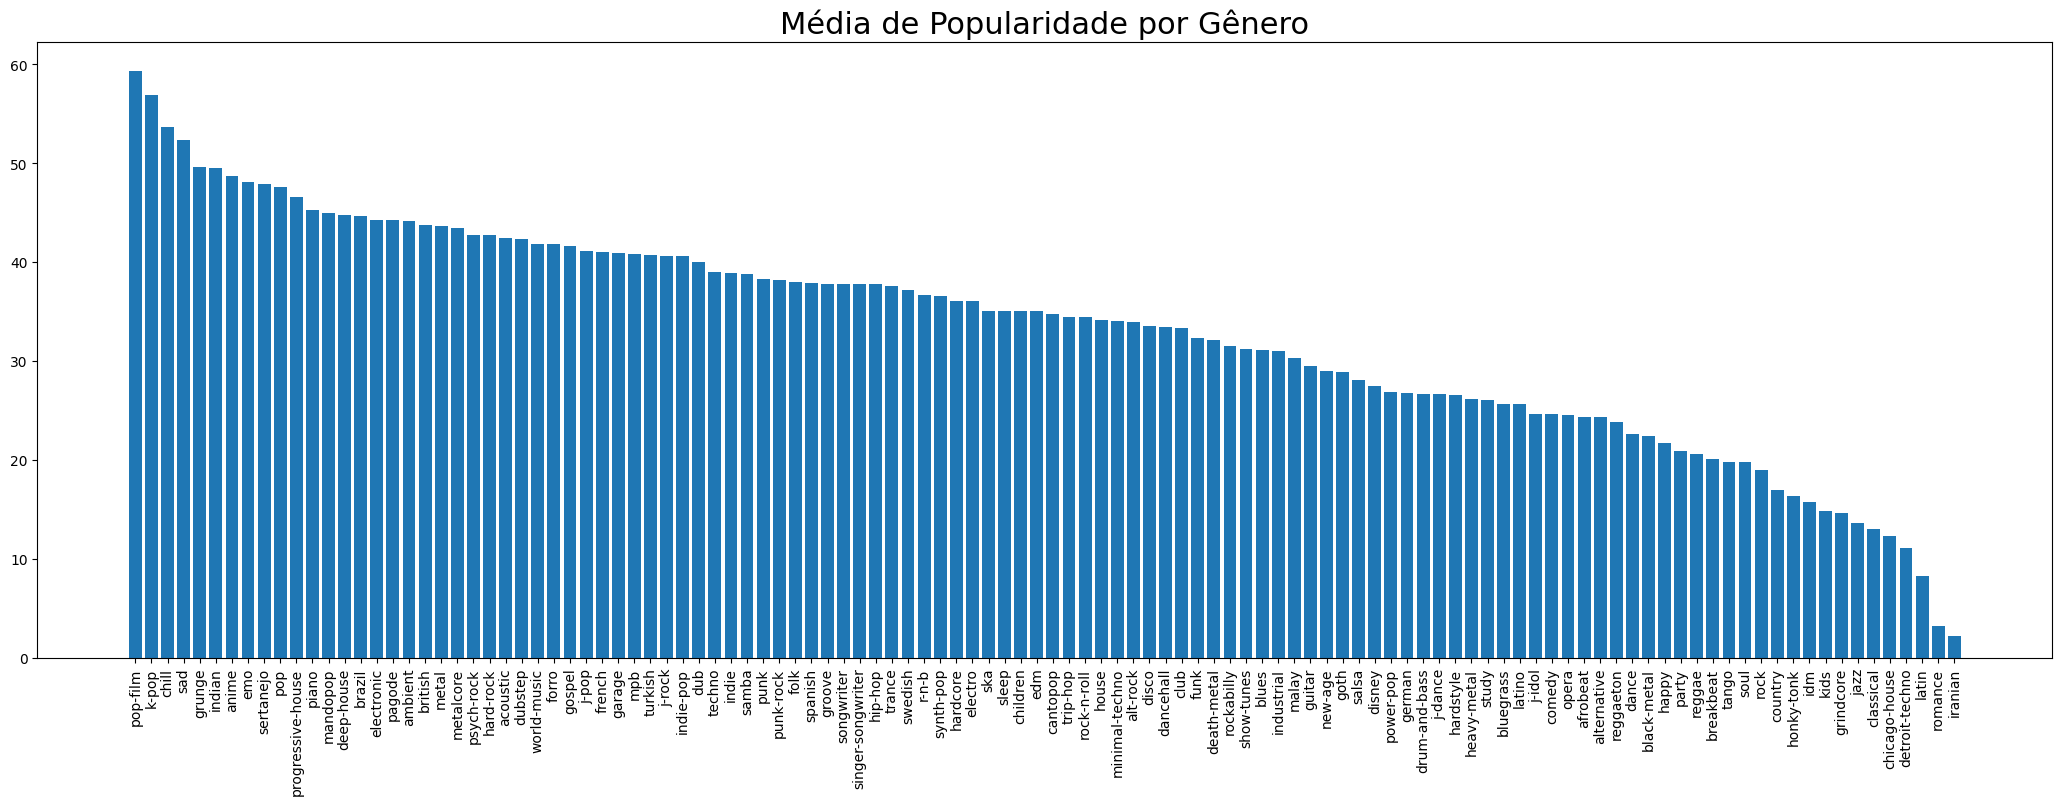

In [7]:
df_ed = pd.DataFrame(resumo_estatistico)
#display(df_ed)



plt.figure(figsize=(26,8))
plt.bar(df_ed.index, df_ed['mean'])
plt.title('Média de Popularidade por Gênero', fontsize = 22)
plt.xticks(rotation = 90)
plt.show()

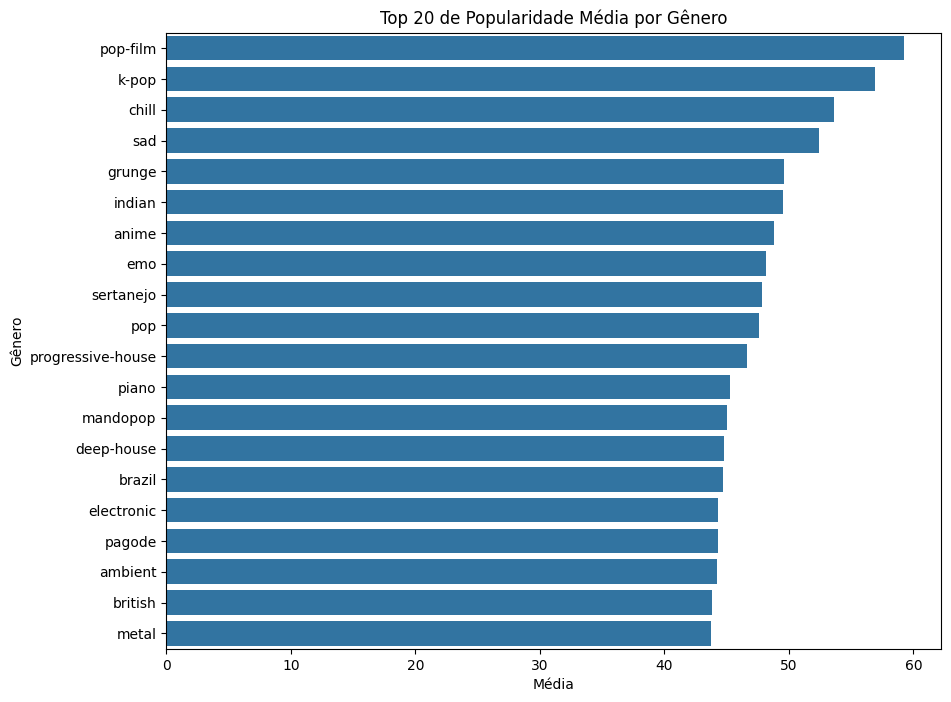

In [ ]:
df_ed2 = df_ed.head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x='mean', y=df_ed2.index, data=df_ed2)
plt.title('Top 20 de Popularidade Média por Gênero')
plt.ylabel('Gênero')
plt.xlabel('Média')
plt.show()

<Axes: >

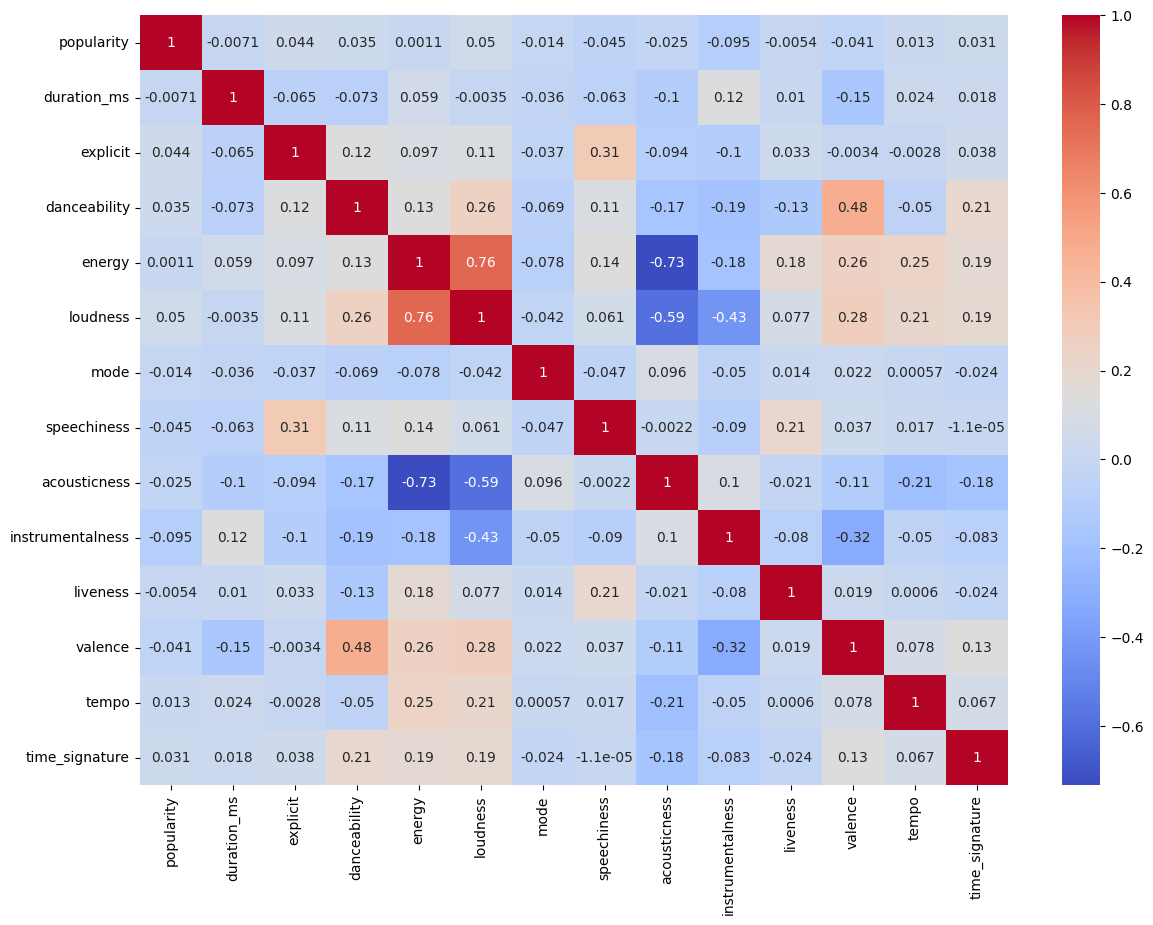

In [9]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot = True, cmap= 'coolwarm')

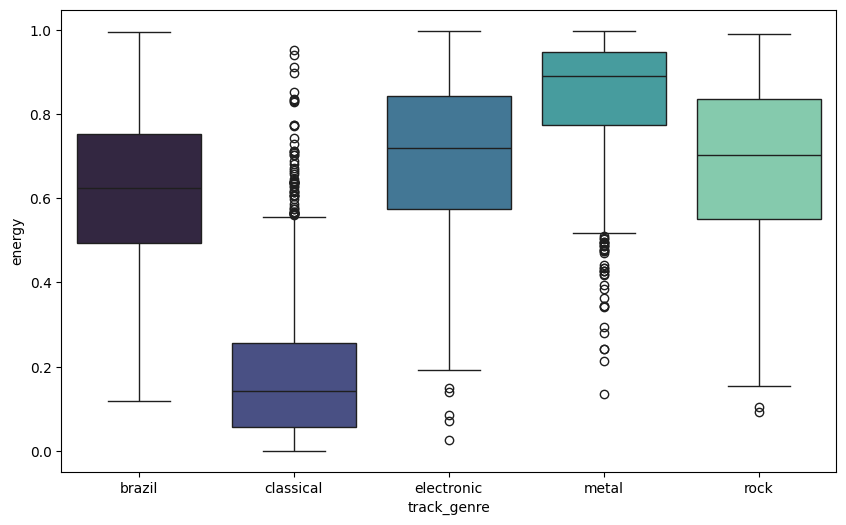

In [ ]:
generos_desejados = ['classical', 'rock', 'metal', 'brazil', 'electronic']
df3 = df[df['track_genre'].isin(generos_desejados)]

plt.figure(figsize=(10,6))
sns.boxplot(data = df3,  
            x = 'track_genre', 
            y = 'energy', 
            hue = 'track_genre', 
            palette='mako', 
            saturation=0.75,
            #showfliers=False,
            legend=False)
plt.show()


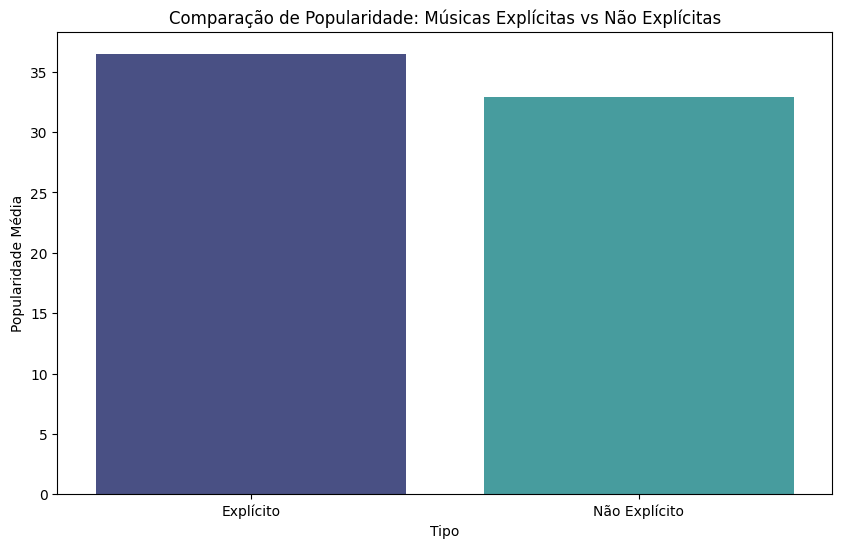

In [11]:
df4 = df[df['explicit']==True]
df5 = df[df['explicit']==False]

media_pop_expl = df4['popularity'].mean()
media_pop_n_expl = df5['popularity'].mean()

#Criando um novo dado auxiliar
data_expl = pd.DataFrame({
    'Tipo': ['Explícito', 'Não Explícito'],
    'Popularidade Média': [media_pop_expl, media_pop_n_expl]
})

plt.figure(figsize=(10,6))
sns.barplot(data=data_expl, x = 'Tipo', y = 'Popularidade Média', hue='Tipo', palette = 'mako')
plt.title('Comparação de Popularidade: Músicas Explícitas vs Não Explícitas')
plt.show()

,popularity
artists,
Sam Smith;Kim Petras,100.0
Bizarrap;Quevedo,99.0
Manuel Turizo,98.0
Bad Bunny;Chencho Corleone,97.0
Bad Bunny;Bomba Estéreo,94.5
Joji,94.0
Beyoncé,93.0
Rema;Selena Gomez,92.0
Harry Styles,92.0


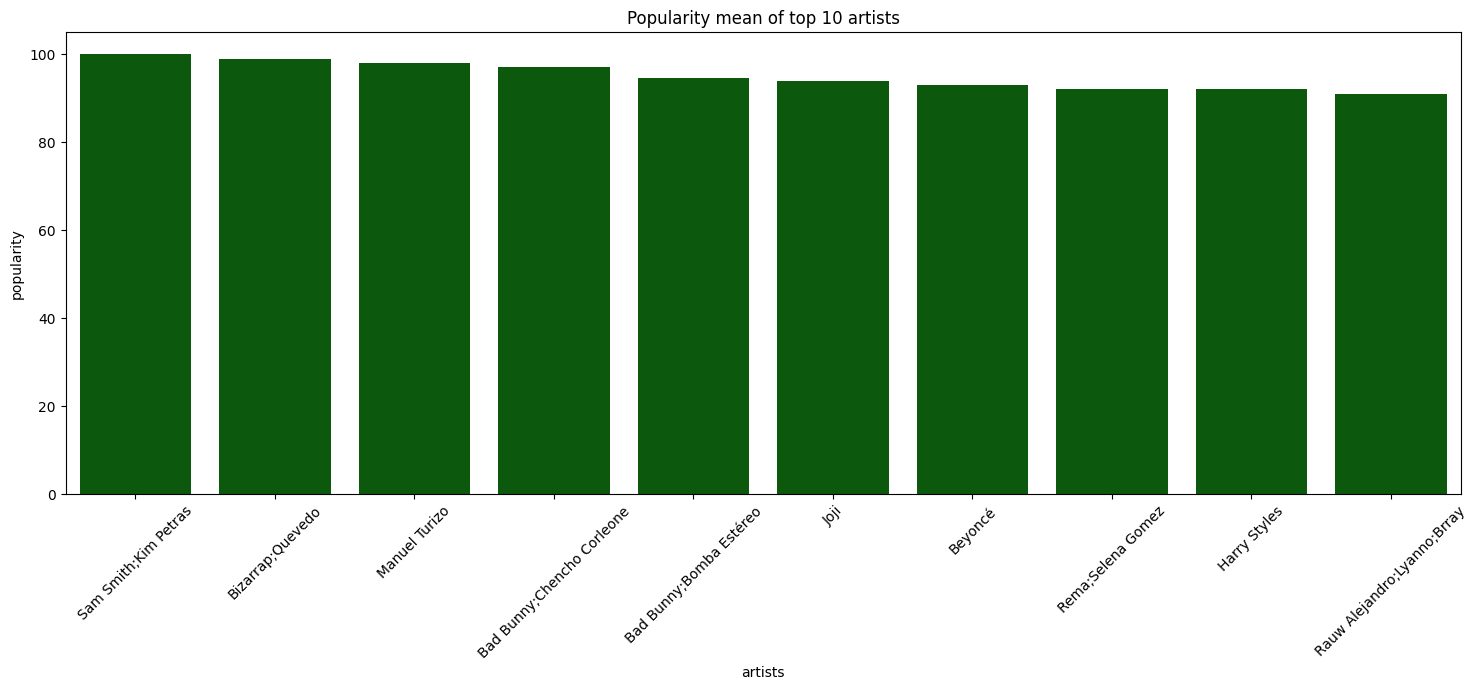

In [12]:
N = 10
df_pop = df.drop('track_name', axis = 1)
df_pop = df_pop.groupby('artists')['popularity'].agg('mean').sort_values(ascending=False).head(N)
df_pop = pd.DataFrame(df_pop)
display(df_pop)

plt.figure(figsize=(18,6))
sns.barplot(data = df_pop, x ='artists', y = 'popularity', color='darkgreen')
plt.title(f'Popularity mean of top {N} artists')
plt.xticks(rotation = 45)
plt.show()

,artists,track_name,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
20001,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance
51664,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop
88410,Manuel Turizo,La Bachata,98,162637,False,0.835,0.679,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,reggae
30003,David Guetta;Bebe Rexha,I'm Good (Blue),98,175238,True,0.561,0.965,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,edm
68304,Bad Bunny,Tití Me Preguntó,97,243716,False,0.650,0.715,-5.198,0,0.2530,0.09930,0.000291,0.1260,0.187,106.672,4,latino
89407,Bad Bunny;Chencho Corleone,Me Porto Bonito,97,178567,True,0.911,0.712,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,reggaeton
67559,Bad Bunny,Efecto,96,213061,False,0.801,0.475,-8.797,0,0.0516,0.14100,0.000017,0.0639,0.234,98.047,4,latin
81003,Chris Brown,Under The Influence,96,184613,True,0.733,0.690,-5.529,0,0.0427,0.06350,0.000001,0.1050,0.310,116.992,4,pop
79000,OneRepublic,I Ain't Worried,96,148485,False,0.704,0.797,-5.927,1,0.0475,0.08260,0.000745,0.0546,0.825,139.994,4,piano
68353,Bad Bunny;Bomba Estéreo,Ojitos Lindos,95,258298,False,0.647,0.686,-5.745,0,0.0413,0.08000,0.000001,0.5280,0.268,79.928,4,latino


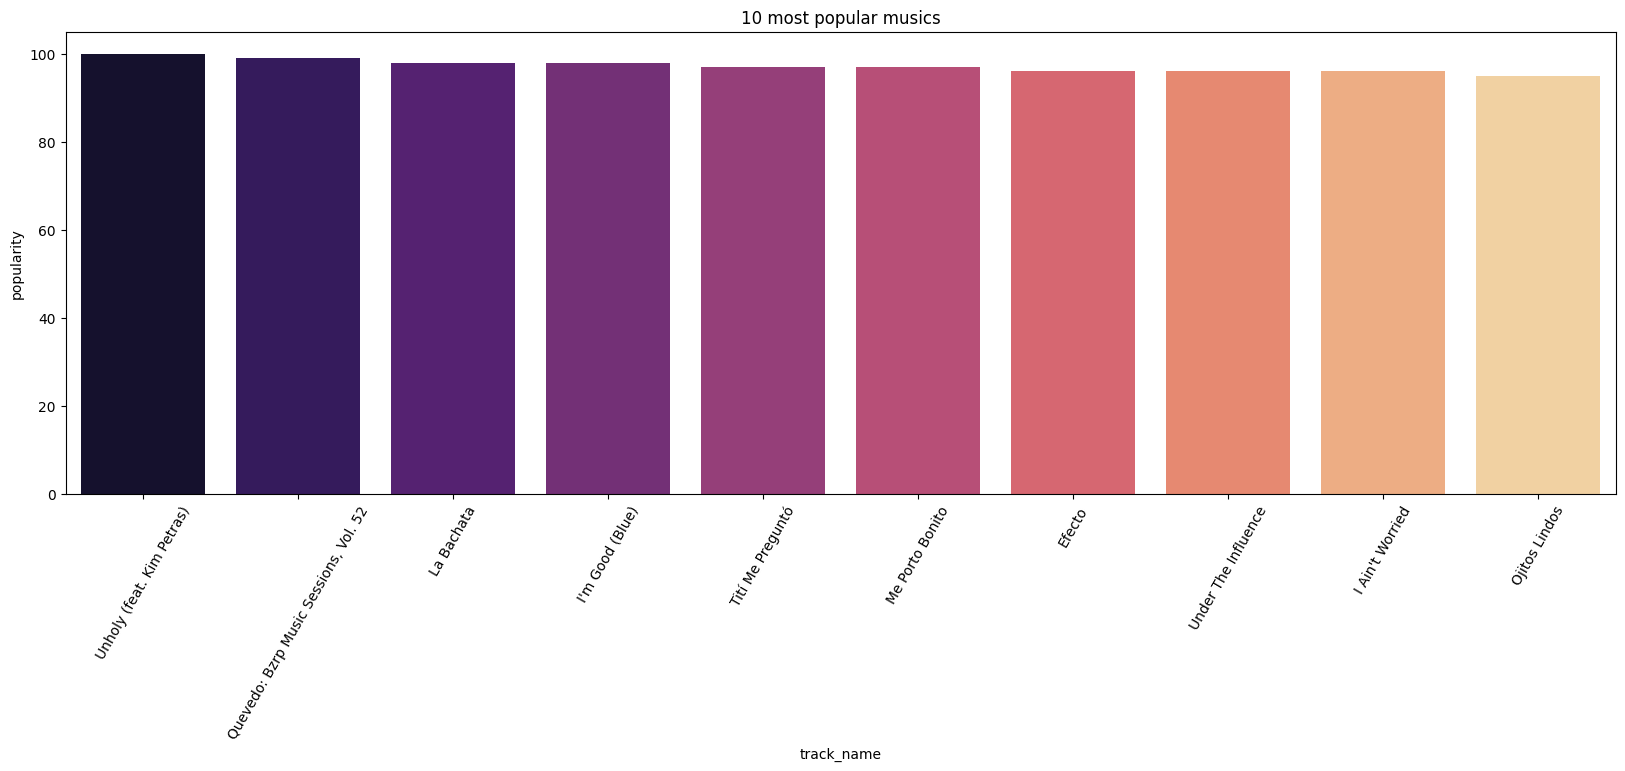

In [ ]:
N = 28
df_pop_music = df.sort_values(by ='popularity', ascending = False).head(N)
df_pop_music = df_pop_music.drop_duplicates(subset=['track_name', 'artists'], keep='first')
display(df_pop_music)


plt.figure(figsize=(20,6))
sns.barplot(data=df_pop_music, x='track_name', y = 'popularity', hue = 'track_name', palette = 'magma')
plt.title('10 most popular musics')
plt.xticks(rotation = 60)
plt.show()

In [ ]:
#Vamos fazer uma pequena previsão de qual música é popular ou não dado uma nota de corte (70) para a popularidade
df['target'] = (df['popularity'] > 60).astype(int)
df['explicit_value'] = np.where(df['explicit'] == True, 1, 0)
display(df)

,artists,track_name,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,target,explicit_value
0,Gen Hoshino,Comedy,73,230666,False,0.676,0.4610,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,1,0
1,Ben Woodward,Ghost - Acoustic,55,149610,False,0.420,0.1660,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,0,0
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,False,0.438,0.3590,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,0,0
3,Kina Grannis,Can't Help Falling In Love,71,201933,False,0.266,0.0596,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,1,0
4,Chord Overstreet,Hold On,82,198853,False,0.618,0.4430,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,Sleep My Little Boy,21,384999,False,0.172,0.2350,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,0,0
113996,Rainy Lullaby,Water Into Light,22,385000,False,0.174,0.1170,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,0,0
113997,Cesária Evora,Miss Perfumado,22,271466,False,0.629,0.3290,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,0,0
113998,Michael W. Smith,Friends,41,283893,False,0.587,0.5060,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report



x = df[['duration_ms','danceability', 'energy', 'loudness', 'mode', 'liveness', 'valence', 'tempo', 'time_signature', 'explicit_value']]
y = df['target']



x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42,  stratify=y)


model = RandomForestClassifier(class_weight='balanced' ,random_state=42, n_estimators=500)

model.fit(x_train, y_train)

predicoes = model.predict(x_test)

print(classification_report(y_test, predicoes))



              precision    recall  f1-score   support

           0       0.94      0.99      0.96     25107
           1       0.84      0.52      0.64      3393

    accuracy                           0.93     28500
   macro avg       0.89      0.75      0.80     28500
weighted avg       0.93      0.93      0.92     28500



In [17]:
from sklearn.model_selection import cross_val_score

# Testando o modelo 5 vezes com partes diferentes dos dados
scores = cross_val_score(model, x, y, cv=5)

print(f"Acurácia média: {scores.mean():.2f}")
print(f"Desvio padrão: {scores.std():.2f}")

Acurácia média: 0.93
Desvio padrão: 0.01


In [ ]:
x_random_df = pd.DataFrame([[230666, 0.676,	0.4610,	-6.746, 1, 0.3580, 0.7150, 87.917, 4, 0]], 
                           columns=['duration_ms','danceability', 'energy', 'loudness', 'mode', 'liveness', 'valence', 'tempo', 'time_signature', 'explicit_value'])

resultado = model.predict(x_random_df)

if resultado == 1:
    print('Essa música provavelmente será popular')

else:
    print('Essa música provavelmente não será popular') 

#print(f"A música aleatória foi classificada como: {resultado[0]}")


Essa música provavelmente será popular
